In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os, json
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd().split("src")[0], "src"))
import core.functions
import core.models as models
import core.datagen as dg
import core.training as ct
import core.utils as utils
import core.ae_tools as aect
import core.mtl_tools as mtlct
from experiments.evolution._lib import id_eval
import experiments.mtl_cue_experiments as mtl_cue_experiments
from core.logger import logger

%load_ext autoreload
%autoreload
    
from IPython.display import clear_output, display

logger()

2026-08-24 02:44:20 | 


## analysis of the receptive fields

In [3]:
# setup
settings_sim = {
    "data_training_size": 50*10,
    "criterion": mtlct.cosine_criterion,
    "reps": 3,
    "use_bias": False,
    "disable": True,
    "plot": False,
    "ae_name": "ae_cue_nb_8"
}

settings_data = {
    "size": 50,
    "K": 5,
    "num_cue_patterns": 2,
    "lap_length": 50,
    "cue_positions": [10., 30.],
    "cue_sigma": 3.,
    "cue_beta": 40.,
    "cue_alpha": 0.2,
    "mec_binarized": True,
    "mec_sigma": 4,
    "cue_spacing": 5,
}

settings_mtl = {
    "K_ca3": 5,
    "K_lat": 15,
    "K_eo": 5,
    "dim_ca3": 50,
    "beta_is": 48,
    "beta_ca3": 196,
    "beta_ca1": 24,
    "beta_eo": 20,
    "alpha": 0.018,
    "nb_ei_ca3": 2,
    "num_swaps_ca1": 1,
    "num_swaps_ca3": 1,
    "random_IS": False,
    "plasticity": "base",
}

settings_mtl_err2 = {
    "K_ca3": 10,
    "dim_ca3": 50,
    "beta_ca3": 81,
    "beta_ca1": 38,
    "alpha": 0.022,
    "nb_ei_ca3": 2,
    "num_swaps_ca1": 1,
    "num_swaps_ca3": 1,
    "random_IS": False,
    "plasticity": "err2",
}

logger()

2026-08-24 02:45:36 | 


In [4]:
num_samples = settings_sim["data_training_size"]
ae_name = settings_sim.get("ae_name", "ae_cue_nb_0")
use_bias = settings_sim.get("use_bias", False)
plot = settings_sim.get("plot", False)
disable = settings_sim.get("disable", False)

autoencoder, info = aect.load_autoencoder(name=ae_name)
params = autoencoder.get_weights(bias=use_bias)

model = models.MTL(W_ei_ca1=params[0],
                   W_ca1_eo=params[1],
                   K_ca1=autoencoder._K_ca1,
                   K_eo=autoencoder._K_eo,
                   K_ca3=settings_mtl["K_ca3"],
                   dim_ca3=settings_mtl["dim_ca3"],
                   beta_is=autoencoder._beta_ei,
                   beta_ca3=settings_mtl["beta_ca3"],
                   beta_ca1=settings_mtl["beta_ca1"],
                   beta_eo=autoencoder._beta_eo,
                   alpha=settings_mtl["alpha"],
                   nb_ei_ca3=int(settings_mtl.get("nb_ei_ca3", 10)),
                   num_swaps_ca3=settings_mtl["num_swaps_ca3"],
                   num_swaps_ca1=settings_mtl["num_swaps_ca1"],
                   B_ei_ca1=params[2],
                   B_ca1_eo=params[3],
                   random_IS=settings_mtl["random_IS"],
                   plasticity=settings_mtl.get("plasticity", "base"))

reps = settings_sim.get("reps", 32)
criterion = settings_sim.get("criterion", mtlct.cosine_criterion)

results = np.zeros((reps, num_samples, num_samples))
rdisable = not(reps > 2)
# for r in tqdm(range(reps), disable=not(rdisable and (not disable))):
for r in tqdm(range(reps), disable=False):

    training_data = mtl_cue_experiments.make_cue_data(
        num_samples=num_samples,
        settings_data=settings_data,
    )

    logs, model = mtlct.train_for_accuracy(data=training_data,
                                           model=model,
                                           criterion=criterion,
                                           disable=True)
    results[r] = logs["rec_loss"]

results = results.mean(axis=0)
score = results.sum()/(len(results)**2/2)
scoreid = id_eval(results).mean()

logger("[done]")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:55<00:00, 18.65s/it]
2026-08-24 02:46:32 | [done]


In [5]:
wca3 = model.W_ei_ca3.detach().numpy()
wca1 = model.W_ca3_ca1.detach().numpy()
wei = model.W_ei_ca1.detach().numpy()
wca3.shape, wca1.shape, wei.shape

((50, 50), (50, 50), (50, 50))

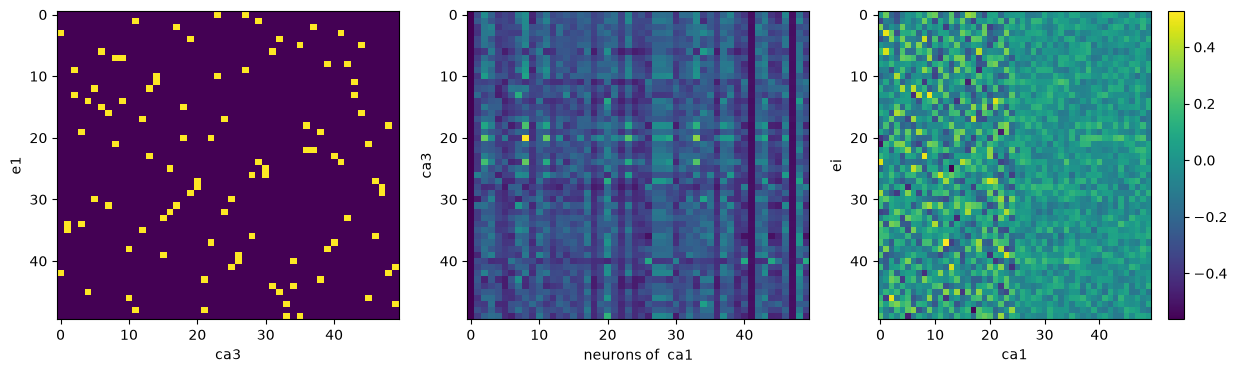

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(5*3, 4))

axs[0].imshow(wca3, aspect="auto")
axs[0].set_ylabel("e1")
axs[0].set_xlabel("ca3")

axs[1].imshow(wca1, aspect="auto")
axs[1].set_ylabel("ca3")
axs[1].set_xlabel("neurons of  ca1")

im = axs[2].imshow(wei, aspect="auto")
axs[2].set_ylabel("ei")
axs[2].set_xlabel("ca1")

plt.colorbar(im)
plt.show()